# SHAP Comparison: All Models

Three mirrored bar chart comparisons:
1. Full Low-MP vs Undersampled Low-MP
2. Undersampled Low-MP vs High-MP
3. Undersampled Low-MP vs Full Combined (All data)

In [8]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

model_prefix     = '../2_model_development/'
data_prefix      = '../0_data/processed_data/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'MP_label']
top_n            = 10

## 1. Load All Models & Data

In [9]:
# ── Undersampled Low-MP ───────────────────────────────────────────────
model_under = joblib.load(f'{model_prefix}best_model_LGB_L_undersample.joblib')
data_under  = pd.read_parquet(data_prefix + 'L_undersampling_scaled.parquet')
X_under     = data_under[data_under['Type'] == 'Test'].drop(columns=non_feature_cols)

# ── Full Low-MP ───────────────────────────────────────────────────────
model_full_L = joblib.load(f'{model_prefix}best_model_LGB_L.joblib')
data_full_L  = pd.read_parquet(data_prefix + 'data_with_selected_features_LGB_L_scaled.parquet')
X_full_L     = data_full_L[data_full_L['Type'] == 'Test'].drop(columns=non_feature_cols)

# ── High-MP ───────────────────────────────────────────────────────────
model_H = joblib.load(f'{model_prefix}best_model_LGB_H.joblib')
data_H  = pd.read_parquet(data_prefix + 'data_with_selected_features_LGB_H_scaled.parquet')
X_H     = data_H[data_H['Type'] == 'Test'].drop(columns=non_feature_cols)

# ── Full Combined (All data) ──────────────────────────────────────────
model_all = joblib.load(f'{model_prefix}best_model_LGB_All.joblib')
data_all  = pd.read_parquet(data_prefix + 'data_with_selected_features_LGB_All_scaled.parquet')
X_all     = data_all[data_all['Type'] == 'Test'].drop(columns=non_feature_cols)

print(f'Undersampled Low-MP test: {X_under.shape}')
print(f'Full Low-MP test:         {X_full_L.shape}')
print(f'High-MP test:             {X_H.shape}')
print(f'Full Combined test:       {X_all.shape}')

Undersampled Low-MP test: (263, 89)
Full Low-MP test:         (5166, 89)
High-MP test:             (5166, 55)
Full Combined test:       (5166, 83)


## 2. Compute SHAP Values for All Models

In [10]:
print('Computing SHAP — Undersampled Low-MP...')
shap_under  = shap.TreeExplainer(model_under).shap_values(X_under)

print('Computing SHAP — Full Low-MP...')
shap_full_L = shap.TreeExplainer(model_full_L).shap_values(X_full_L)

print('Computing SHAP — High-MP...')
shap_H      = shap.TreeExplainer(model_H).shap_values(X_H)

print('Computing SHAP — Full Combined...')
shap_all    = shap.TreeExplainer(model_all).shap_values(X_all)

print('Done.')

Computing SHAP — Undersampled Low-MP...
Computing SHAP — Full Low-MP...
Computing SHAP — High-MP...
Computing SHAP — Full Combined...
Done.


## 3. Helper Functions

In [11]:
def top_mean_shap(shap_values, feature_names, n=10):
    """Return top-n features sorted by mean |SHAP| descending."""
    return (
        pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
        .sort_values(ascending=False)
        .head(n)
    )


def mirrored_shap_plot(left_shap, right_shap,
                       left_label, right_label,
                       left_xlabel, right_xlabel,
                       title, color_left, color_right,
                       save_path=None):
    """Draw a mirrored horizontal bar chart comparing two SHAP distributions."""

    left_sorted  = left_shap.sort_values(ascending=True)
    right_sorted = right_shap.sort_values(ascending=True)
    n = len(left_sorted)
    x_max = max(left_shap.max(), right_shap.max()) * 1.15

    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor('white')

    fig.text(0.5, 0.97, title,
             ha='center', va='top',
             fontsize=13, fontweight='bold',
             color='black', fontfamily='monospace')

    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.05)
    ax_l = fig.add_subplot(gs[0])
    ax_r = fig.add_subplot(gs[1])

    for ax in [ax_l, ax_r]:
        ax.set_facecolor('white')
        ax.spines[['top', 'right']].set_visible(False)

    # Left panel (reversed x-axis)
    ax_l.barh(range(n), left_sorted.values, color=color_left, edgecolor='white')
    ax_l.set_xlim(x_max, 0)
    ax_l.set_yticks(range(n))
    ax_l.set_yticklabels(left_sorted.index, ha='right', fontsize=12, color=color_left)
    ax_l.set_xlabel(left_xlabel, fontsize=11)
    ax_l.set_title(left_label, color=color_left, fontsize=12)
    ax_l.tick_params(axis='x', labelsize=11)
    ax_l.spines['left'].set_visible(False)
    ax_l.yaxis.set_tick_params(left=False)

    # Right panel
    ax_r.barh(range(n), right_sorted.values, color=color_right, edgecolor='white')
    ax_r.set_xlim(0, x_max)
    ax_r.set_yticks(range(n))
    ax_r.set_yticklabels(right_sorted.index, ha='left', fontsize=12, color=color_right)
    ax_r.yaxis.set_label_position('right')
    ax_r.yaxis.tick_right()
    ax_r.set_xlabel(right_xlabel, fontsize=11)
    ax_r.set_title(right_label, color=color_right, fontsize=12)
    ax_r.tick_params(axis='x', labelsize=11)
    ax_r.spines['right'].set_visible(False)

    # Centre divider — drawn at x=0 on each axis so it aligns with the zero baseline
    ax_l.axvline(x=0, color='#999999', linewidth=1.2, zorder=3)
    ax_r.axvline(x=0, color='#999999', linewidth=1.2, zorder=3)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved: {save_path}')
    plt.show()


def overlap_summary(shap_a, shap_b, label_a, label_b):
    """Print shared vs unique top features between two SHAP rankings."""
    shared = set(shap_a.index) & set(shap_b.index)
    only_a = set(shap_a.index) - set(shap_b.index)
    only_b = set(shap_b.index) - set(shap_a.index)
    print(f'  Shared ({len(shared)}):          {sorted(shared)}')
    print(f'  Only in {label_a} ({len(only_a)}): {sorted(only_a)}')
    print(f'  Only in {label_b} ({len(only_b)}): {sorted(only_b)}')

## 4. Comparison 1 — Full Low-MP vs Undersampled Low-MP

Saved: shap_comparison_1_undersampleL_vs_fullL.png


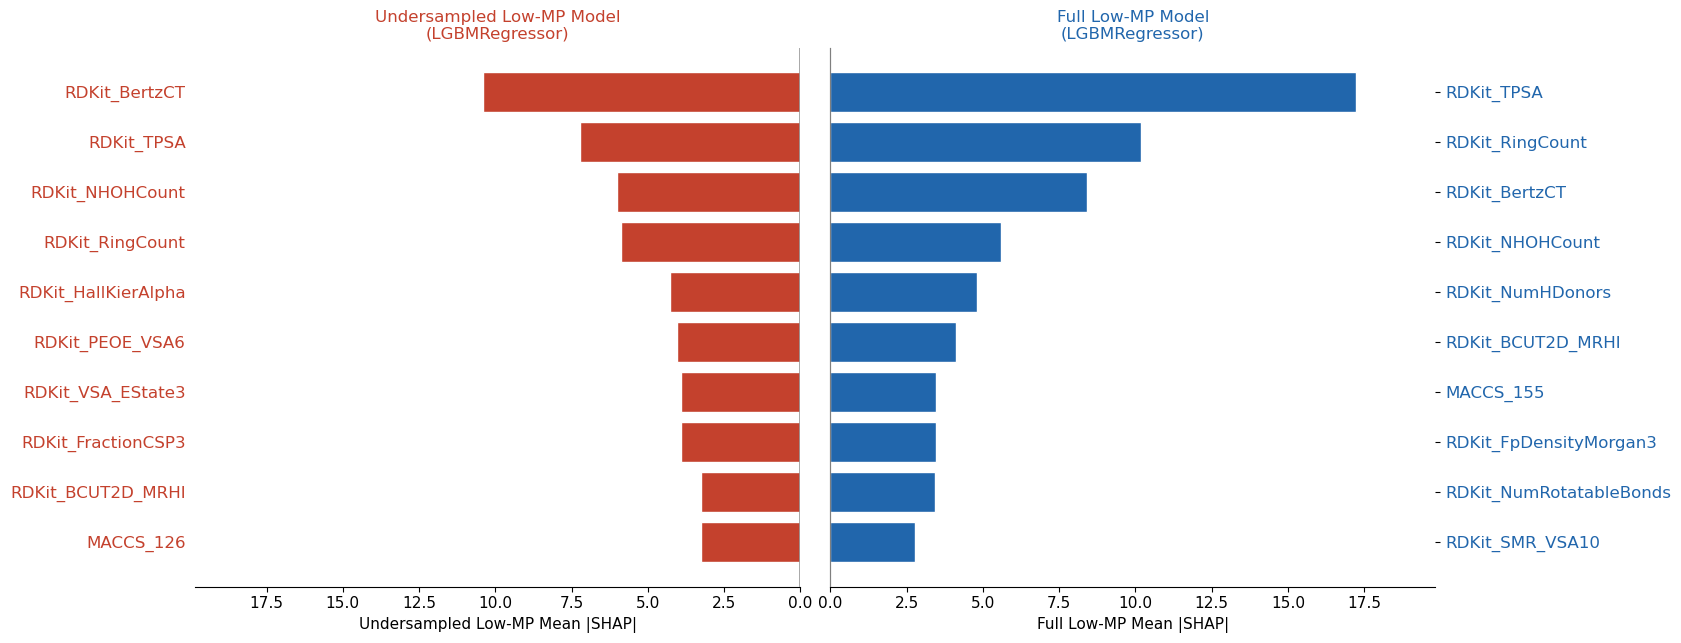


Feature overlap:
  Shared (5):          ['RDKit_BCUT2D_MRHI', 'RDKit_BertzCT', 'RDKit_NHOHCount', 'RDKit_RingCount', 'RDKit_TPSA']
  Only in Undersampled Low-MP (5): ['MACCS_126', 'RDKit_FractionCSP3', 'RDKit_HallKierAlpha', 'RDKit_PEOE_VSA6', 'RDKit_VSA_EState3']
  Only in Full Low-MP (5): ['MACCS_155', 'RDKit_FpDensityMorgan3', 'RDKit_NumHDonors', 'RDKit_NumRotatableBonds', 'RDKit_SMR_VSA10']


In [16]:
top_full_L = top_mean_shap(shap_full_L, X_full_L.columns, top_n)
top_under  = top_mean_shap(shap_under,  X_under.columns,  top_n)

mirrored_shap_plot(
    left_shap    = top_under,
    right_shap   = top_full_L,
    left_label   = 'Undersampled Low-MP Model\n(LGBMRegressor)',
    right_label  = 'Full Low-MP Model\n(LGBMRegressor)',
    left_xlabel  = 'Undersampled Low-MP Mean |SHAP|',
    right_xlabel = 'Full Low-MP Mean |SHAP|',
    title        = '',
    color_left   = "#C4412D",
    color_right  = '#2166AC',
    save_path    = 'shap_comparison_1_undersampleL_vs_fullL.png'
)

print('\nFeature overlap:')
overlap_summary(top_under, top_full_L, 'Undersampled Low-MP', 'Full Low-MP')

## 5. Comparison 2 — Undersampled Low-MP vs High-MP

Saved: shap_comparison_2_undersampleL_vs_H.png


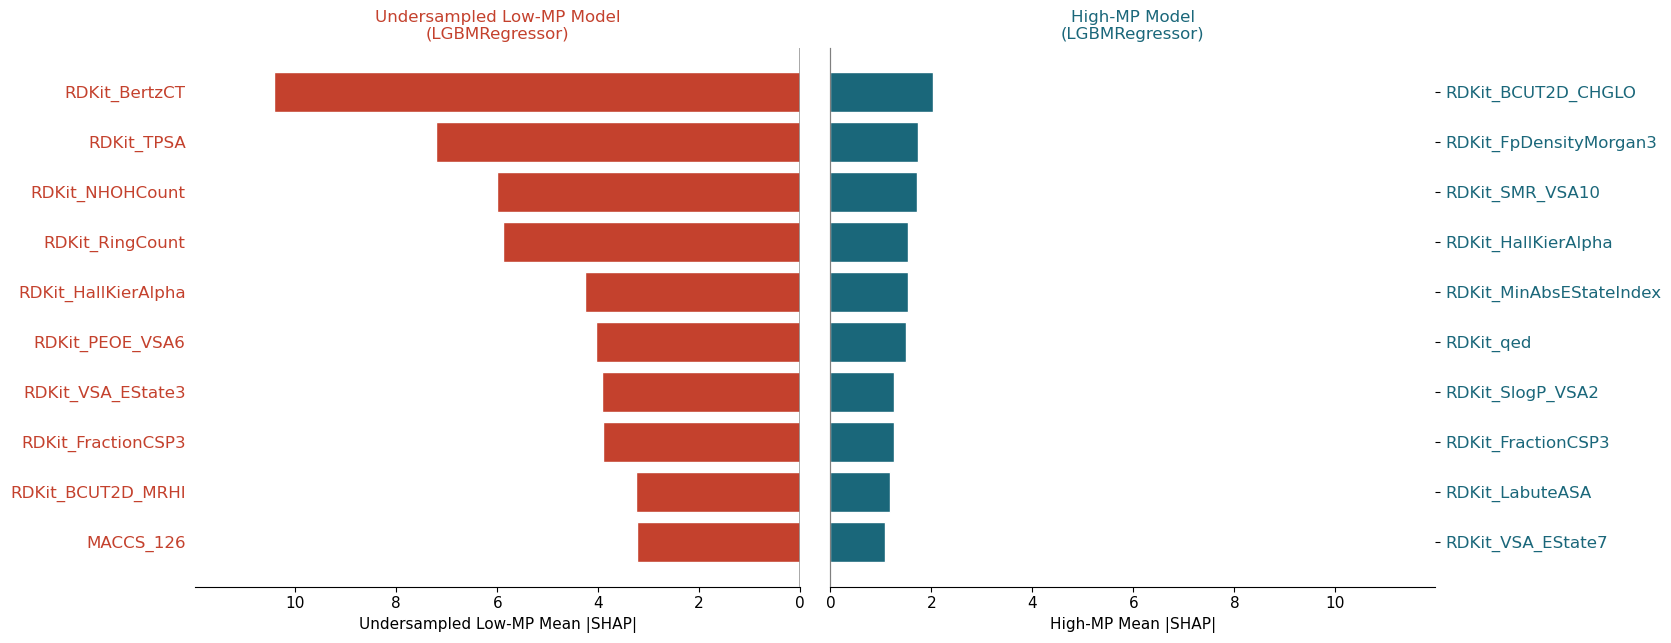


Feature overlap:
  Shared (2):          ['RDKit_FractionCSP3', 'RDKit_HallKierAlpha']
  Only in Undersampled Low-MP (8): ['MACCS_126', 'RDKit_BCUT2D_MRHI', 'RDKit_BertzCT', 'RDKit_NHOHCount', 'RDKit_PEOE_VSA6', 'RDKit_RingCount', 'RDKit_TPSA', 'RDKit_VSA_EState3']
  Only in High-MP (8): ['RDKit_BCUT2D_CHGLO', 'RDKit_FpDensityMorgan3', 'RDKit_LabuteASA', 'RDKit_MinAbsEStateIndex', 'RDKit_SMR_VSA10', 'RDKit_SlogP_VSA2', 'RDKit_VSA_EState7', 'RDKit_qed']


In [17]:
top_H = top_mean_shap(shap_H, X_H.columns, top_n)

mirrored_shap_plot(
    left_shap    = top_under,
    right_shap   = top_H,
    left_label   = 'Undersampled Low-MP Model\n(LGBMRegressor)',
    right_label  = 'High-MP Model\n(LGBMRegressor)',
    left_xlabel  = 'Undersampled Low-MP Mean |SHAP|',
    right_xlabel = 'High-MP Mean |SHAP|',
    title        = '',
    color_left   = "#C4412D",
    color_right  = "#1A677A",
    save_path    = 'shap_comparison_2_undersampleL_vs_H.png'
)

print('\nFeature overlap:')
overlap_summary(top_under, top_H, 'Undersampled Low-MP', 'High-MP')

## 6. Comparison 3 — Undersampled Low-MP vs Full Combined Model

Saved: shap_comparison_3_undersampleL_vs_all.png


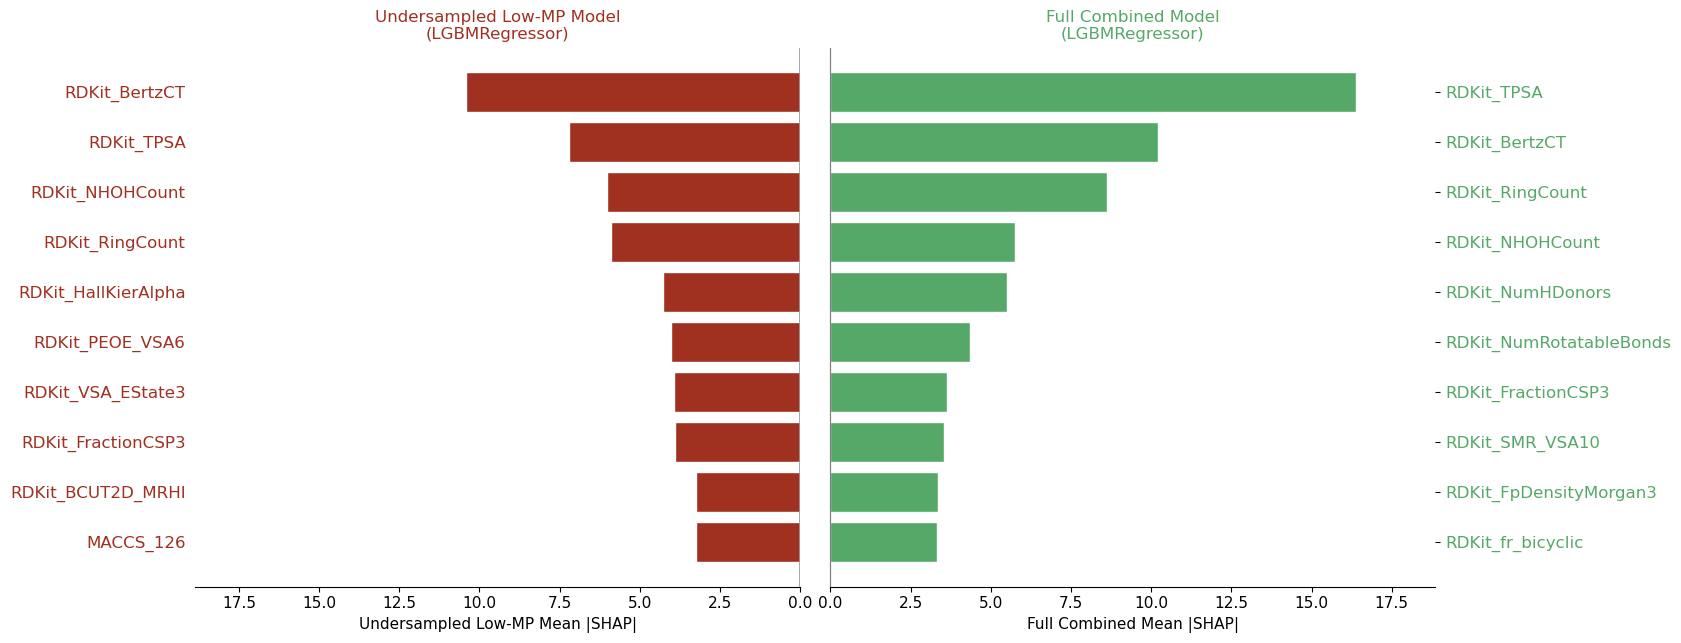


Feature overlap:
  Shared (5):          ['RDKit_BertzCT', 'RDKit_FractionCSP3', 'RDKit_NHOHCount', 'RDKit_RingCount', 'RDKit_TPSA']
  Only in Undersampled Low-MP (5): ['MACCS_126', 'RDKit_BCUT2D_MRHI', 'RDKit_HallKierAlpha', 'RDKit_PEOE_VSA6', 'RDKit_VSA_EState3']
  Only in Full Combined (5): ['RDKit_FpDensityMorgan3', 'RDKit_NumHDonors', 'RDKit_NumRotatableBonds', 'RDKit_SMR_VSA10', 'RDKit_fr_bicyclic']


In [14]:
top_all = top_mean_shap(shap_all, X_all.columns, top_n)

mirrored_shap_plot(
    left_shap    = top_under,
    right_shap   = top_all,
    left_label   = 'Undersampled Low-MP Model\n(LGBMRegressor)',
    right_label  = 'Full Combined Model\n(LGBMRegressor)',
    left_xlabel  = 'Undersampled Low-MP Mean |SHAP|',
    right_xlabel = 'Full Combined Mean |SHAP|',
    title        = '',
    color_left   = '#A03020',
    color_right  = '#55A868',
    save_path    = 'shap_comparison_3_undersampleL_vs_all.png'
)

print('\nFeature overlap:')
overlap_summary(top_under, top_all, 'Undersampled Low-MP', 'Full Combined')